# Case Study 09 — Map and Test a Protein Interface

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/uw-ipd/tmol/blob/master/docs/tutorial/09_protein_interface_hotspot_scan.ipynb)

Which side chains appear to stabilize a protein–protein interface, and what
happens when they are replaced by alanine? This capstone follows one scientific
question through structure inspection, score decomposition, a batched local
repacking experiment, and interactive comparison of the resulting structures.

## Learning objectives

- Define an interface from author chain labels rather than block positions.
- Rank residue contributions from both orientations of a block-pair score tensor.
- Run matched WT/alanine local-repacking tasks in one `PoseStack` batch.
- Separate one-complex score changes from thermodynamic binding ΔΔG.

## Before you begin

- **Prerequisites:** [03 — Scoring](03_scoring_and_analysis.ipynb) and [04 — Packing](04_packing_and_mutation_scan.ipynb).
- **Related:** [Protein-interface workflow](../workflows/protein_interfaces.md) · [Packing API](../api/pack.rst) · [Scoring API](../api/score.rst)

The example extracts neighboring chains A and B from the checked-in KcsA
tetramer structure (PDB 1BL8). It therefore analyzes one subunit interface, not
the complete tetramer or a membrane-aware binding process. The workflow uses
weighted TMol score units; it does not estimate kcal/mol or experimental
affinity.

## Setup

The setup fixes PyTorch's random seed, loads protein atoms from chains A and B,
and optimizes hydrogen coordinates before interpreting all-atom scores. TMol's
CPU packer uses a C random stream that `torch.manual_seed()` does not control;
the CPU results below are illustrative single outcomes rather than replicates.

In [1]:
try:
    import google.colab  # noqa: F401
except ImportError:
    IN_COLAB = False
else:
    IN_COLAB = True

if IN_COLAB:
    from urllib.request import urlopen

    exec(
        urlopen(
            "https://raw.githubusercontent.com/uw-ipd/tmol/"
            "master/docs/tutorial/colab_setup.py"
        ).read(),
        globals(),
    )
    setup_colab(["tmol/tests/data/cif/1BL8.cif"])

In [2]:
from contextlib import redirect_stderr, redirect_stdout
from io import StringIO
from pathlib import Path
from time import perf_counter
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from biotite.structure.io import load_structure

import tmol
from tmol.database import ParameterDatabase
from tmol.io import pose_stack_from_biotite
from tmol.ops import (
    calculate_block_pair_ddg,
    compute_block_adjacency,
    compute_block_centroids_and_furthest_dist,
    res_mask_to_coord_mask,
)
from tmol.pack import PackerPalette, PackerTask, pack_rotamers
from tmol.pack.rotamer import FixedAAChiSampler, IncludeCurrentSampler
from tmol.pack.rotamer.dunbrack import create_dunbrack_sampler_from_database
from tmol.pose import PoseStackBuilder
from tmol.score import ScoreType, beta2016_score_function

SEED = 20260829
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
warnings.filterwarnings(
    "ignore", message=r"Sparse invariant checks are implicitly disabled.*"
)

device = (
    torch.device("cuda", torch.cuda.current_device())
    if torch.cuda.is_available()
    else torch.device("cpu")
)
repo_root = Path.cwd()
if not (repo_root / "tmol/tests/data/cif/1BL8.cif").exists():
    repo_root = Path(tmol.__file__).resolve().parents[1]
cif_path = repo_root / "tmol/tests/data/cif/1BL8.cif"

atom_array = load_structure(str(cif_path), model=1, include_bonds=True)
protein_dimer = atom_array[
    ((atom_array.chain_id == "A") | (atom_array.chain_id == "B")) & ~atom_array.hetero
]
param_db = ParameterDatabase.get_default()
pose_diagnostics = StringIO()
try:
    with redirect_stdout(pose_diagnostics), redirect_stderr(pose_diagnostics):
        pose_stack = pose_stack_from_biotite(
            protein_dimer,
            device,
            param_db=param_db,
            no_optH=False,
        )
except Exception:
    print(pose_diagnostics.getvalue())
    raise

score_function = beta2016_score_function(device, param_db=param_db)


def show_table(frame):
    try:
        from itables import show
    except ImportError:
        display(frame)
        return None
    return show(frame)


def block_label(pose, block_index):
    chain = pose.pdb_info.chain_labels[0, block_index]
    residue = pose.pdb_info.residue_labels[0, block_index]
    insertion = pose.pdb_info.residue_insertion_codes[0, block_index]
    return f"{chain}:{residue}{insertion}"


chain_labels = pose_stack.pdb_info.chain_labels[0]
chain_a = torch.tensor([str(label) == "A" for label in chain_labels], device=device)
chain_b = torch.tensor([str(label) == "B" for label in chain_labels], device=device)
assert int(chain_a.sum()) == int(chain_b.sum()) == 97
print(
    f"device={device}; input={cif_path.name}; "
    f"blocks={pose_stack.max_n_blocks}; chains=A+B"
)

device=cpu; input=1BL8.cif; blocks=194; chains=A+B


## Inspect the extracted neighboring-subunit interface

The author chain labels survive pose construction and define the two partners.
The viewer highlights chain A in blue within the extracted A–B dimer. This is a
specific neighboring interface from the crystallographic tetramer; chains C and
D, membrane context, ions, solvent, and separated partners are outside this
case study.

In [3]:
chain_a_atoms = res_mask_to_coord_mask(pose_stack, chain_a.unsqueeze(0))
try:
    interface_viewer = tmol.view(
        pose_stack,
        highlighted=chain_a_atoms[pose_stack.real_atoms],
        highlight_color="#2563eb",
    )
    print("Blue: chain A; unhighlighted partner: chain B.")
    interface_viewer.show()
except ImportError as exc:
    print("Interactive interface viewer unavailable:", exc)

Blue: chain A; unhighlighted partner: chain B.


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Map native interface contributions

The block-pair scorer stores each unordered interaction in one directed matrix
entry. For every A–B pair, the analysis therefore adds `A→B` and `B→A` before
ranking residues. The hotspot ranking uses five explicit nonbonded terms:
`fa_ljatr`, `fa_ljrep`, `fa_lk`, `fa_elec`, and `hbond`. The complete all-term
cross-chain reduction is independently checked with
`calculate_block_pair_ddg()` despite that helper's historical name.

The heat map is an energetic accounting view of this one fixed complex, not a
contact probability or experimental residue contribution. Negative values are
more favorable under the chosen weighted-term subset.

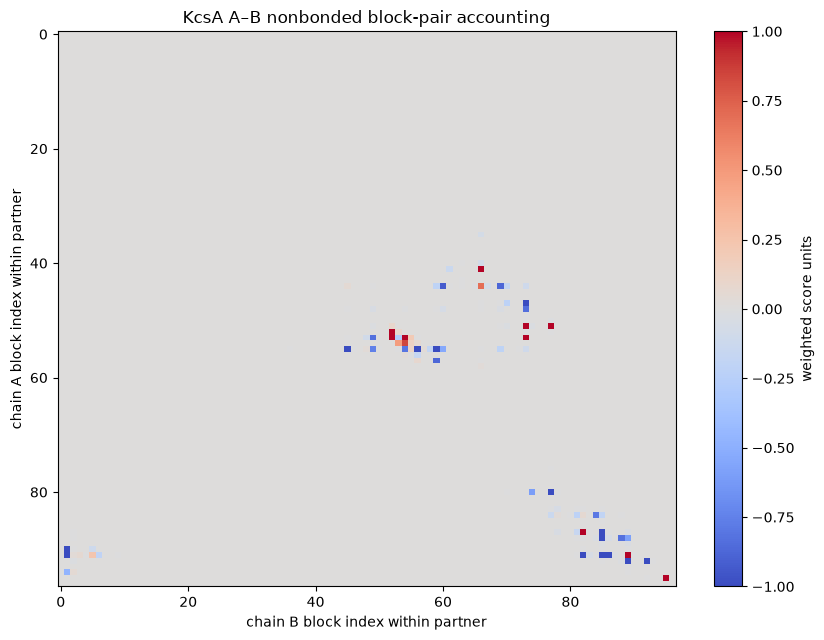

In [4]:
block_scorer = score_function.render_block_pair_scoring_module(pose_stack)
weighted_by_term = block_scorer(pose_stack.coords, sum_terms=False, apply_weights=True)
score_types = score_function.all_score_types()

forward = weighted_by_term[:, 0][:, chain_a][:, :, chain_b]
reverse = weighted_by_term[:, 0][:, chain_b][:, :, chain_a].transpose(1, 2)
pair_by_term = forward + reverse
all_term_interface = pair_by_term.sum(dim=(1, 2))

chain_a_batch = chain_a.unsqueeze(0)
chain_b_batch = chain_b.unsqueeze(0)
helper_interface = calculate_block_pair_ddg(
    pose_stack,
    chain_a_batch,
    chain_b_batch,
    sfxn=score_function,
    sum_terms=False,
    minimize=False,
    pack=False,
)[:, 0]
torch.testing.assert_close(all_term_interface, helper_interface)

nonbonded_types = [
    ScoreType.fa_ljatr,
    ScoreType.fa_ljrep,
    ScoreType.fa_lk,
    ScoreType.fa_elec,
    ScoreType.hbond,
]
nonbonded_indices = [score_types.index(term) for term in nonbonded_types]
nonbonded_pairs = pair_by_term[nonbonded_indices].sum(dim=0)

chain_a_blocks = torch.nonzero(chain_a, as_tuple=False).flatten()
chain_b_blocks = torch.nonzero(chain_b, as_tuple=False).flatten()
chain_a_contributions = nonbonded_pairs.sum(dim=1)
chain_b_contributions = nonbonded_pairs.sum(dim=0)


def contribution_rows(blocks, contributions):
    rows = []
    for local_index, block_index_tensor in enumerate(blocks):
        block_index = int(block_index_tensor)
        rows.append(
            {
                "block_index": block_index,
                "author_label": block_label(pose_stack, block_index),
                "identity": pose_stack.block_type(0, block_index).name3,
                "five_term_interface_score": float(
                    contributions[local_index].detach().cpu()
                ),
            }
        )
    return rows


contribution_frame = pd.DataFrame(
    contribution_rows(chain_a_blocks, chain_a_contributions)
    + contribution_rows(chain_b_blocks, chain_b_contributions)
).sort_values("five_term_interface_score")
show_table(contribution_frame.head(16))

fig, ax = plt.subplots(figsize=(8.5, 6.5))
image = ax.imshow(
    nonbonded_pairs.detach().cpu(),
    cmap="coolwarm",
    aspect="auto",
    vmin=-max(1.0, float(nonbonded_pairs.abs().quantile(0.99).detach().cpu())),
    vmax=max(1.0, float(nonbonded_pairs.abs().quantile(0.99).detach().cpu())),
)
ax.set(
    xlabel="chain B block index within partner",
    ylabel="chain A block index within partner",
    title="KcsA A–B nonbonded block-pair accounting",
)
fig.colorbar(image, ax=ax, label="weighted score units")
plt.tight_layout()
plt.show()

**Expected observations.** Most of the dense matrix is near zero, while a
limited band of cross-chain pairs carries the interface score. Summing both
matrix orientations is essential: a single row or column can omit a stored
interaction. The table includes both chains and uses author labels, so its
rank does not depend on assuming that chain A occupies blocks 0–96.

## Choose three native hotspots

For a compact alanine-scan demonstration, select the three most favorable
chain-A contributors that are internal residues and are not already alanine or
glycine. This rule is stated in code rather than silently hard-coding residue
numbers. It chooses sites from the native fixed-structure decomposition; the
subsequent repacking experiment is a separate calculation.

In [5]:
chain_a_block_list = chain_a_blocks.detach().cpu().tolist()
eligible = contribution_frame[
    (contribution_frame["author_label"].str.startswith("A:"))
    & ~contribution_frame["identity"].isin({"ALA", "GLY"})
    & contribution_frame["block_index"].isin(chain_a_block_list[1:-1])
]
hotspot_frame = eligible.head(3).copy().reset_index(drop=True)
hotspot_blocks = hotspot_frame["block_index"].astype(int).tolist()
assert len(hotspot_blocks) == 3
show_table(hotspot_frame)

hotspot_mask = torch.zeros_like(chain_a)
hotspot_mask[hotspot_blocks] = True
hotspot_atoms = res_mask_to_coord_mask(pose_stack, hotspot_mask.unsqueeze(0))
try:
    hotspot_viewer = tmol.view(
        pose_stack,
        highlighted=hotspot_atoms[pose_stack.real_atoms],
        highlight_color="#f97316",
    )
    print("Orange hotspots: " + ", ".join(hotspot_frame["author_label"].tolist()))
    hotspot_viewer.show()
except ImportError as exc:
    print("Interactive hotspot viewer unavailable:", exc)

Orange hotspots: A:78, A:103, A:115


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Test alanine substitutions in one packing batch

Each site contributes two batch members: an independently repacked WT control
and an alanine variant. Both use the same geometry-defined local packing shell.
All blocks outside that shell remain fixed, every non-target block retains its
identity, and the mutation target is restricted to alanine in only its mutant
member.

`compute_block_adjacency()` uses enclosing residue spheres plus a 5 Å gap, so
the shell is deliberately conservative rather than an exact atom-contact set.
The batch exposes independent site/state work to one packer call. One outcome
per state is enough to demonstrate the API, but not to estimate sampling
uncertainty or establish convergence.

In [6]:
requests = [
    (block_index, state)
    for block_index in hotspot_blocks
    for state in ("repacked WT", "ALA")
]
scan_batch = PoseStackBuilder.from_poses([pose_stack] * len(requests), device)
scan_task = PackerTask(scan_batch, PackerPalette())

mutation_mask = torch.zeros_like(scan_batch.block_type_ind, dtype=torch.bool)
for pose_index, (block_index, state) in enumerate(requests):
    if state == "ALA":
        mutation_mask[pose_index, block_index] = True

# Restrictions only remove choices. Preserve the original identity everywhere
# except mutant targets, then restrict those targets to alanine.
scan_task.restrict_to_repacking(~mutation_mask)
scan_task.restrict_absent_name3s({"ALA"}, mutation_mask)

centroids, radii = compute_block_centroids_and_furthest_dist(pose_stack)
adjacency = compute_block_adjacency(centroids, radii)
packing_shells = torch.zeros_like(scan_batch.block_type_ind, dtype=torch.bool)
for pose_index, (block_index, _) in enumerate(requests):
    packing_shells[pose_index] = adjacency[0, block_index]
    packing_shells[pose_index, block_index] = True
scan_task.disable_packing_by_block_mask(~packing_shells)

scan_task.add_conformer_sampler(create_dunbrack_sampler_from_database(param_db, device))
scan_task.add_conformer_sampler(FixedAAChiSampler())
scan_task.add_conformer_sampler(IncludeCurrentSampler())

torch.manual_seed(SEED)  # Controls CUDA annealing, not the CPU C RNG stream.
if device.type == "cuda":
    torch.cuda.synchronize()
scan_start = perf_counter()
packed_scan = pack_rotamers(scan_batch, score_function, scan_task)
if device.type == "cuda":
    torch.cuda.synchronize()
scan_seconds = perf_counter() - scan_start

for pose_index, (target_block, state) in enumerate(requests):
    expected = "ALA" if state == "ALA" else pose_stack.block_type(0, target_block).name3
    assert packed_scan.block_type(pose_index, target_block).name3 == expected
    for block_index in range(pose_stack.max_n_blocks):
        if block_index != target_block:
            assert (
                packed_scan.block_type(pose_index, block_index).name3
                == pose_stack.block_type(0, block_index).name3
            )

print(
    f"packed {len(requests)} site/state members in {scan_seconds:.3f} s; "
    f"shell sizes={packing_shells.sum(dim=1).detach().cpu().tolist()}"
)

packed 6 site/state members in 5.475 s; shell sizes=[41, 41, 41, 41, 24, 24]


## Compare matched site/state calculations

The interface score sums all weighted terms crossing chain A and chain B. The
target-to-partner score uses one integer target block per batch member and
chain B as its partner mask; this indexed reduction avoids constructing a
dense target mask. Whole-pose totals provide a third diagnostic. Every mutant
value is compared only with the independently repacked WT member for the same
site and shell.

These are **one-complex score changes**, not binding or stability ΔΔGs. There
is no separated state, unfolded state, membrane model, solvent correction,
backbone relaxation, experimental calibration, or sampling ensemble.

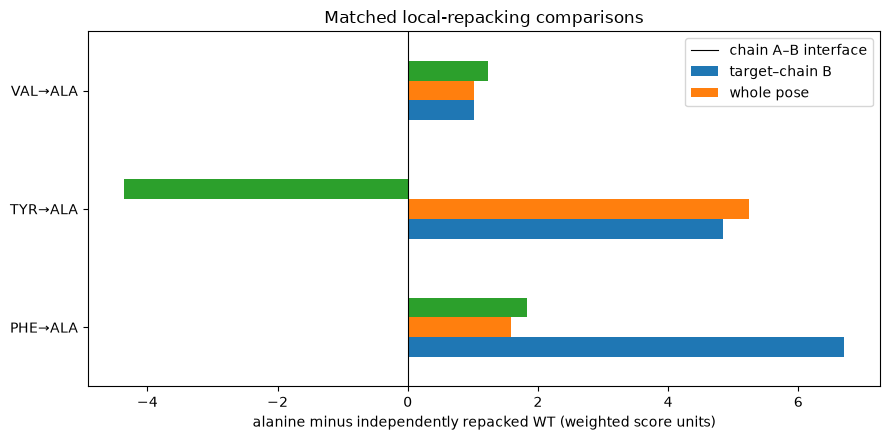

In [7]:
chain_a_scan = chain_a.unsqueeze(0).expand(len(requests), -1).clone()
chain_b_scan = chain_b.unsqueeze(0).expand(len(requests), -1).clone()
interface_scores = calculate_block_pair_ddg(
    packed_scan,
    chain_a_scan,
    chain_b_scan,
    sfxn=score_function,
    minimize=False,
    pack=False,
)

target_indices = torch.tensor(
    [block_index for block_index, _ in requests],
    dtype=torch.int64,
    device=device,
)
target_partner_by_term = calculate_block_pair_ddg(
    packed_scan,
    target_indices,
    chain_b_scan,
    sfxn=score_function,
    sum_terms=False,
    minimize=False,
    pack=False,
)
target_partner_scores = target_partner_by_term.sum(dim=0)

whole_scorer = score_function.render_whole_pose_scoring_module(packed_scan)
whole_scores = whole_scorer(packed_scan.coords)

comparison_rows = []
term_change_rows = []
variant_poses = {}
variant_notes = {}
for site_index, target_block in enumerate(hotspot_blocks):
    wt_index = 2 * site_index
    mutant_index = wt_index + 1
    author_label = block_label(pose_stack, target_block)
    native_identity = pose_stack.block_type(0, target_block).name3
    comparison_rows.append(
        {
            "site": author_label,
            "mutation": f"{native_identity}→ALA",
            "packing_shell_blocks": int(packing_shells[wt_index].sum()),
            "interface_score_change_non_ddg": float(
                (interface_scores[mutant_index] - interface_scores[wt_index])
                .detach()
                .cpu()
            ),
            "target_partner_score_change_non_ddg": float(
                (target_partner_scores[mutant_index] - target_partner_scores[wt_index])
                .detach()
                .cpu()
            ),
            "whole_pose_score_change_non_ddg": float(
                (whole_scores[mutant_index] - whole_scores[wt_index]).detach().cpu()
            ),
        }
    )
    for term_index, score_type in enumerate(score_types):
        term_change_rows.append(
            {
                "site": author_label,
                "term": score_type.name,
                "target_partner_score_change": float(
                    (
                        target_partner_by_term[term_index, mutant_index]
                        - target_partner_by_term[term_index, wt_index]
                    )
                    .detach()
                    .cpu()
                ),
            }
        )
    for member_index, state in ((wt_index, "repacked WT"), (mutant_index, "ALA")):
        key = f"{author_label} · {state}"
        variant_poses[key] = packed_scan.split(member_index)
        variant_notes[key] = (
            f"{native_identity}→{packed_scan.block_type(member_index, target_block).name3}; "
            f"same {int(packing_shells[member_index].sum())}-block packing shell"
        )

comparison_frame = pd.DataFrame(comparison_rows).sort_values(
    "interface_score_change_non_ddg", ascending=False
)
show_table(comparison_frame)

plot_frame = comparison_frame.set_index("mutation")[
    [
        "interface_score_change_non_ddg",
        "target_partner_score_change_non_ddg",
        "whole_pose_score_change_non_ddg",
    ]
]
ax = plot_frame.plot.barh(figsize=(9, 4.5))
ax.axvline(0.0, color="black", linewidth=0.8)
ax.set(
    xlabel="alanine minus independently repacked WT (weighted score units)",
    ylabel="",
    title="Matched local-repacking comparisons",
)
ax.legend(
    ["chain A–B interface", "target–chain B", "whole pose"],
    loc="best",
)
plt.tight_layout()
plt.show()

In [8]:
term_change_frame = pd.DataFrame(term_change_rows)
term_change_frame["absolute_change"] = term_change_frame[
    "target_partner_score_change"
].abs()
dominant_term_changes = (
    term_change_frame.sort_values("absolute_change", ascending=False)
    .groupby("site", as_index=False, group_keys=False)
    .head(5)
    .sort_values(["site", "absolute_change"], ascending=[True, False])
)
show_table(dominant_term_changes.drop(columns="absolute_change"))

try:
    display(
        tmol.switchable_view(
            variant_poses,
            notes=variant_notes,
            width=760,
            height=440,
        )
    )
except ImportError as exc:
    print("Interactive mutation comparison unavailable:", exc)

**Expected observations.** The three alanine substitutions need not affect the
full interface and their target-to-partner interactions by the same amount:
local shell repacking redistributes interactions beyond the mutated side chain.
A favorable native fixed-structure contribution does not guarantee a large
post-repacking change. Large repulsive terms, extreme structural movement, or
non-finite values should trigger inspection rather than automatic biological
interpretation.

The structure selector keeps each WT and alanine member side by side. It is a
visual check on the actual packed structures, not just the score table. Because
only one stochastic outcome is shown for each state, repeat the batch with
several outcomes before discussing rank stability.

## Rosetta and PyRosetta comparison

Rosetta and PyRosetta provide mature alanine-scanning, interface analysis,
residue selectors, TaskOperations, docking, and binding-energy protocol layers.
This TMol example composes lower-level tensor APIs explicitly: author-label
masks, block-pair score accounting, `PackerTask` restrictions, one batched
packer call, and declared score reductions. It does not reproduce a Rosetta
InterfaceAnalyzer or point-mutation protocol, and the numerical results are not
cross-package parity claims.

The scientific progression follows the Rosetta tutorials: inspect the input,
state the score convention, choose movable residues, run one controlled change,
analyze terms and structures, and document what the result cannot establish.

## Exercises

1. Scan five or ten chain-A sites and compare one large batch with chunked batches.
2. Add several packing outcomes per WT/mutant state and plot their distributions.
3. Replace the conservative enclosing-sphere shell with an explicitly documented atom-distance shell.
4. Minimize identical local coordinate masks after packing and compare pre/post-minimization rankings.
5. Repeat the analysis for A–D, another neighboring interface in the tetramer, and test symmetry consistency.

## References

- Doyle et al., [The structure of the potassium channel: molecular basis of K+ conduction and selectivity](https://pubmed.ncbi.nlm.nih.gov/9525859/)
- [Rosetta scoring tutorial](https://docs.rosettacommons.org/demos/latest/tutorials/scoring/scoring)
- [Rosetta packer tutorial](https://docs.rosettacommons.org/demos/latest/tutorials/Optimizing_Sidechains_The_Packer/Optimizing_Sidechains_The_Packer)
- [Rosetta analysis tutorial](https://docs.rosettacommons.org/demos/latest/tutorials/analysis/Analysis)
- [PyRosetta point-mutation scan](https://nbviewer.org/github/RosettaCommons/PyRosetta.notebooks/blob/master/notebooks/06.08-Point-Mutation-Scan.ipynb)
- [PyRosetta distributed ddG/PSSM example](https://nbviewer.org/github/RosettaCommons/PyRosetta.notebooks/blob/master/notebooks/16.01-PyData-ddG-pssm.ipynb)